# Household Animals Classification (multi-class): VGG16 vs EfficientNetV2B0
.

In [1]:
import tensorflow as tf
print("TensorFlow", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow 2.21.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Downloading the Animals-10 dataset

In [ ]:
import os, getpass
os.environ["KAGGLE_API_TOKEN"] = getpass.getpass("token")

!pip install -q -U kaggle
!kaggle datasets download -d alessiocorrado99/animals10 -p /content
!unzip -q -o /content/animals10.zip -d /content/animals
!ls /content/animals

## 2. Renaming the Italian folder names to English

In [3]:
import os
root = "/content/animals/raw-img"
rename = {"cane": "dog", "cavallo": "horse", "elefante": "elephant", "farfalla": "butterfly",
          "gallina": "chicken", "gatto": "cat", "mucca": "cow", "pecora": "sheep",
          "ragno": "spider", "scoiattolo": "squirrel"}
for it, en in rename.items():
    src, dst = f"{root}/{it}", f"{root}/{en}"
    if os.path.exists(src) and not os.path.exists(dst):
        os.rename(src, dst)
print(sorted(os.listdir(root)))

['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


## 3. Removing unreadable images

In [4]:
import os, tensorflow as tf
root = "/content/animals/raw-img"
bad, total = 0, 0
for c in sorted(os.listdir(root)):
    for f in os.listdir(f"{root}/{c}"):
        p = f"{root}/{c}/{f}"
        total += 1
        try:
            img = tf.io.decode_image(tf.io.read_file(p), channels=3, expand_animations=False)
            if img.shape[0] < 16 or img.shape[1] < 16:
                raise ValueError("too small")
        except Exception:
            os.remove(p)
            bad += 1
print(f"Checked {total} images, removed {bad} unreadable ones")

Checked 26179 images, removed 0 unreadable ones


## 4. Imports and config

In [5]:
import os, time, gc, json, random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, EfficientNetV2B0
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay

SEED = 42
IMG = 224      # image size used by VGG16 and EfficientNetV2B0
BS = 16        # small batch size keeps RAM low on free Colab
root = "/content/animals/raw-img"
tf.keras.utils.set_random_seed(SEED)
print("GPU:", tf.config.list_physical_devices("GPU"))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


10 classes, 26179 images
{'butterfly': 2112, 'cat': 1668, 'chicken': 3098, 'cow': 1866, 'dog': 4863, 'elephant': 1446, 'horse': 2623, 'sheep': 1820, 'spider': 4821, 'squirrel': 1862}


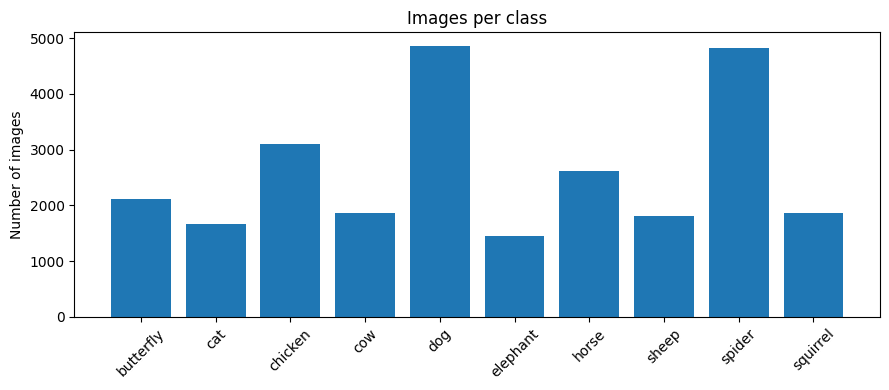

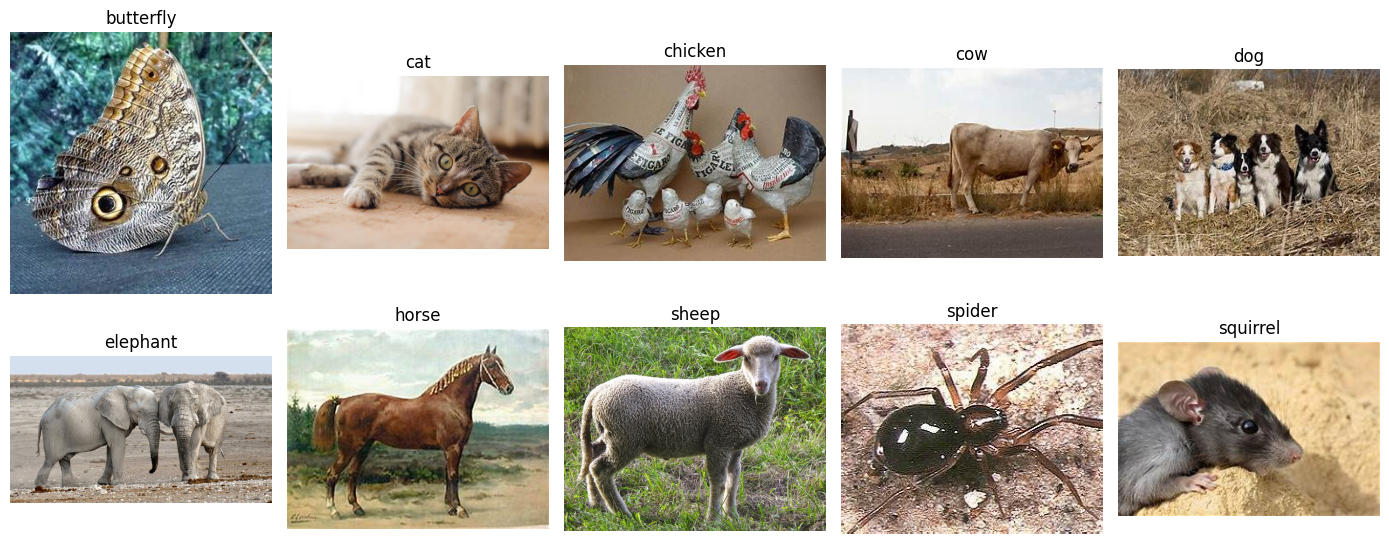

In [6]:
class_names = sorted(os.listdir(root))
NUM_CLASSES = len(class_names)
counts = {c: len(os.listdir(f"{root}/{c}")) for c in class_names}
print(NUM_CLASSES, "classes,", sum(counts.values()), "images")
print(counts)

plt.figure(figsize=(9, 4))
plt.bar(list(counts.keys()), list(counts.values()))
plt.xticks(rotation=45)
plt.ylabel("Number of images")
plt.title("Images per class")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax in axes.flat:
    ax.axis("off")
for ax, c in zip(axes.flat, class_names):
    f = random.choice(os.listdir(f"{root}/{c}"))
    ax.imshow(Image.open(f"{root}/{c}/{f}").convert("RGB"))
    ax.set_title(c)
plt.tight_layout()
plt.show()

## 5. Train / validation / test split (70 / 15 / 15)

In [7]:
files, labels = [], []
for i, c in enumerate(class_names):
    for f in os.listdir(f"{root}/{c}"):
        files.append(f"{root}/{c}/{f}")
        labels.append(i)
files, labels = np.array(files), np.array(labels)

f_tr, f_rest, l_tr, l_rest = train_test_split(files, labels, test_size=0.3, stratify=labels, random_state=SEED)
f_va, f_te, l_va, l_te = train_test_split(f_rest, l_rest, test_size=0.5, stratify=l_rest, random_state=SEED)
split = {"train": (f_tr, l_tr), "val": (f_va, l_va), "test": (f_te, l_te)}
print(NUM_CLASSES, class_names)
print({k: len(v[0]) for k, v in split.items()})

10 ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']
{'train': 18325, 'val': 3927, 'test': 3927}


## 6. Data pipeline (resize, preprocessing) and augmentation

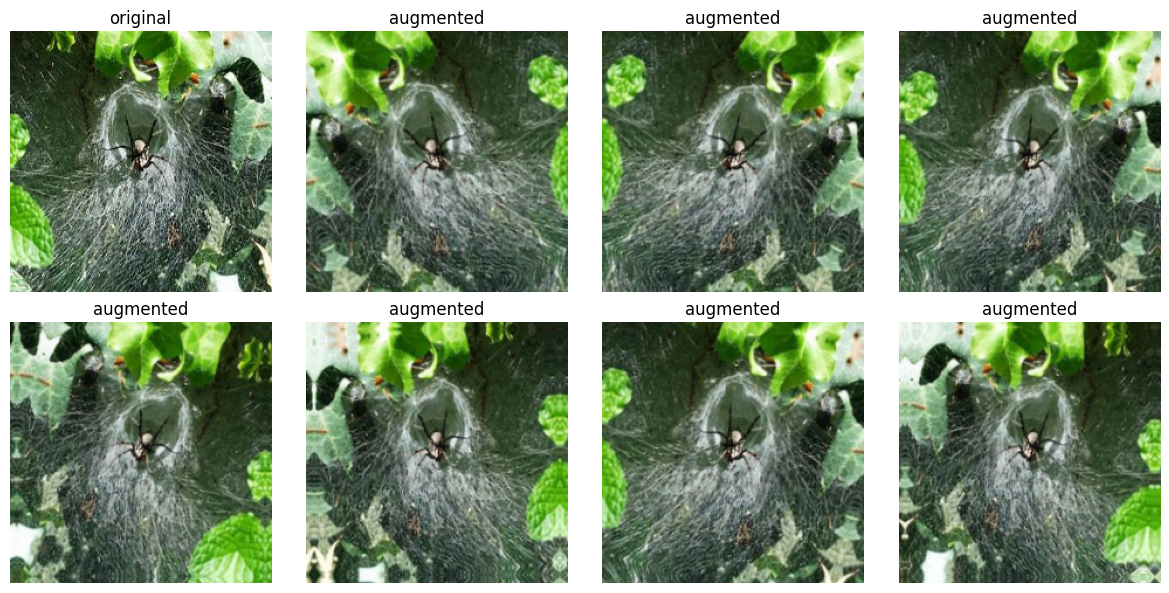

In [8]:
def make_ds(name, size=IMG, pre=None, bs=BS):
    paths, labs = split[name]

    def load(p, y):
        img = tf.io.decode_image(tf.io.read_file(p), channels=3, expand_animations=False)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, (size, size))      # every image becomes 224 x 224 x 3
        if pre is not None:
            img = pre(img)                            # model-specific pixel scaling
        return img, tf.cast(y, tf.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labs))
    if name == "train":
        ds = ds.shuffle(2000, seed=SEED)
    return ds.map(load, num_parallel_calls=2).batch(bs).prefetch(1)


def make_aug():
    # random changes applied only while training, so the model sees more variety
    return tf.keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ])


# show what augmentation does to one image
demo_img, _ = next(iter(make_ds("train", bs=1)))
aug_demo = make_aug()
plt.figure(figsize=(12, 6))
plt.subplot(2, 4, 1)
plt.imshow(np.clip(demo_img[0].numpy(), 0, 255).astype("uint8"))
plt.title("original")
plt.axis("off")
for i in range(7):
    plt.subplot(2, 4, i + 2)
    out = aug_demo(demo_img, training=True)[0].numpy()
    plt.imshow(np.clip(out, 0, 255).astype("uint8"))
    plt.title("augmented")
    plt.axis("off")
plt.tight_layout()
plt.show()

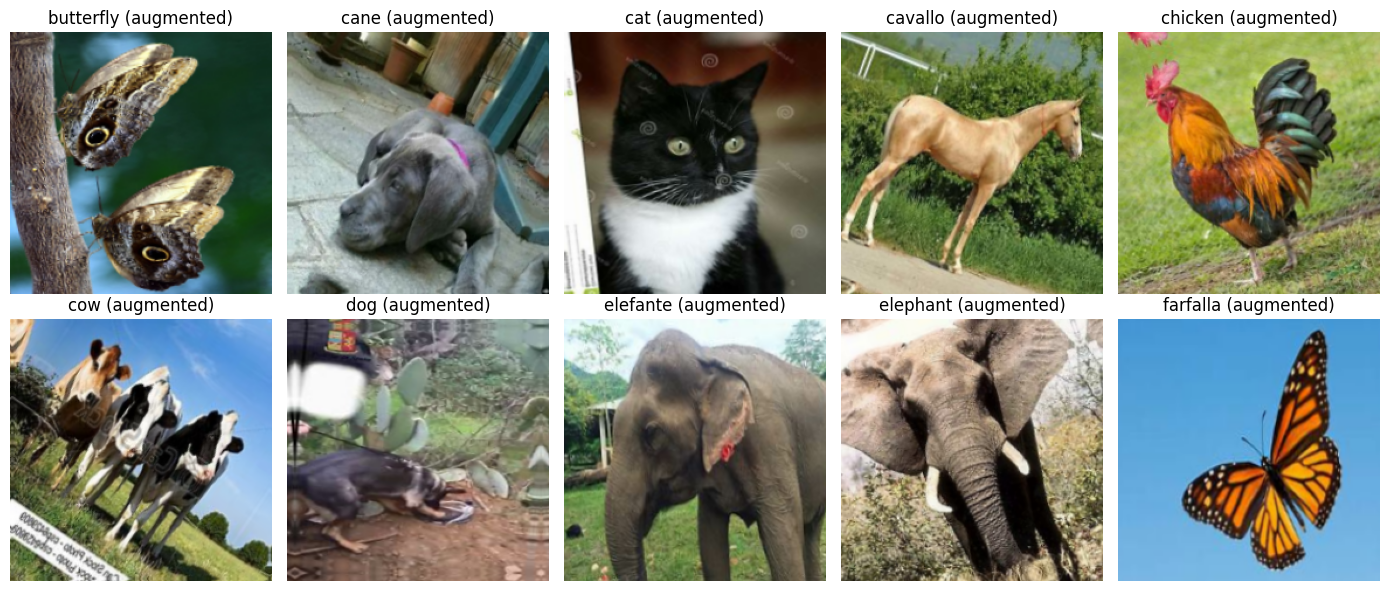

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
aug_demo = make_aug()
for ax, c in zip(axes.flat, class_names):
    f = random.choice(os.listdir(f"{root}/{c}"))
    img = tf.io.decode_image(tf.io.read_file(f"{root}/{c}/{f}"), channels=3, expand_animations=False)
    img = tf.image.resize(img, (IMG, IMG))[None]
    out = aug_demo(img, training=True)[0].numpy()
    ax.imshow(np.clip(out, 0, 255).astype("uint8"))
    ax.set_title(c + " (augmented)")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 7. Helper functions (plots, evaluation, results table)

In [9]:
results = json.load(open("results.json")) if os.path.exists("results.json") else {}


def plot_history(h, title):
    fig, ax = plt.subplots(1, 2, figsize=(11, 4))
    ax[0].plot(h.history["accuracy"], label="train")
    ax[0].plot(h.history["val_accuracy"], label="validation")
    ax[0].set_title(title + " - Accuracy")
    ax[0].set_xlabel("Epochs")
    ax[0].legend()
    ax[1].plot(h.history["loss"], label="train")
    ax[1].plot(h.history["val_loss"], label="validation")
    ax[1].set_title(title + " - Loss")
    ax[1].set_xlabel("Epochs")
    ax[1].legend()
    plt.show()


def evaluate_model(model, ds, name):
    y_true, y_pred = [], []
    for x, y in ds:      # labels and predictions are collected in the same pass, so they always match
        p = model(x, training=False).numpy()
        y_pred.extend(np.argmax(p, axis=1))
        y_true.extend(y.numpy().flatten())
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    acc = float((y_true == y_pred).mean())
    f1 = float(f1_score(y_true, y_pred, average="macro"))
    print(f"{name} test accuracy: {acc * 100:.2f}%   macro F1: {f1 * 100:.2f}%")
    fig, ax = plt.subplots(figsize=(8, 8))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=class_names,
                                            xticks_rotation=45, ax=ax, colorbar=False)
    ax.set_title(name + " - Confusion matrix")
    plt.tight_layout()
    plt.show()
    print(classification_report(y_true, y_pred, target_names=class_names))
    return acc, f1


def record(name, model, acc, f1, seconds):
    trainable = int(sum(np.prod(w.shape) for w in model.trainable_weights))
    results[name] = {"test_acc_%": round(acc * 100, 2), "macro_f1_%": round(f1 * 100, 2),
                     "train_time_min": round(seconds / 60, 1),
                     "total_params": int(model.count_params()), "trainable_params": trainable}
    json.dump(results, open("results.json", "w"), indent=2)
    print(results[name])


def build(base_fn):
    base = base_fn(weights="imagenet", include_top=False, input_shape=(IMG, IMG, 3))
    base.trainable = False                    # frozen: keep the pretrained knowledge
    inp = layers.Input((IMG, IMG, 3))
    x = make_aug()(inp)
    x = base(x, training=False)
    # your new top layers (the only part trained in the first phase)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(NUM_CLASSES, activation="softmax")(x)   # one probability per animal
    return models.Model(inp, out), base

## 8. Model 1: VGG16 (transfer learning, pretrained base frozen)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/8
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 107s 88ms/step - accuracy: 0.7991 - loss: 0.7351 - val_accuracy: 0.9340 - val_loss: 0.2157
Epoch 2/8
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 101s 88ms/step - accuracy: 0.8764 - loss: 0.3879 - val_accuracy: 0.9427 - val_loss: 0.2027
Epoch 3/8
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 142s 88ms/step - accuracy: 0.8918 - loss: 0.3413 - val_accuracy: 0.9417 - val_loss: 0.2113
Epoch 4/8
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 105s 91ms/step - accuracy: 0.9007 - loss: 0.3206 - val_accuracy: 0.9503 - val_loss: 0.1975
Epoch 5/8
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 107s 93ms/step - accuracy: 0.9072 - loss: 0.3032 - val_accuracy: 0.9529 - val_loss: 0.1847
Epoch 6/8
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 108s 94ms/step - accuracy: 0.9088 - loss: 0.2917 - val_accuracy: 0.9478 - val_loss: 0.1825
Epoch 7/8
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 108s 95ms/step - accuracy: 0.9136 - loss: 0.2773 - val_accuracy: 0.9460 - val_loss: 0.2005
Epoch 8/8
1146/1146 ━━━━━

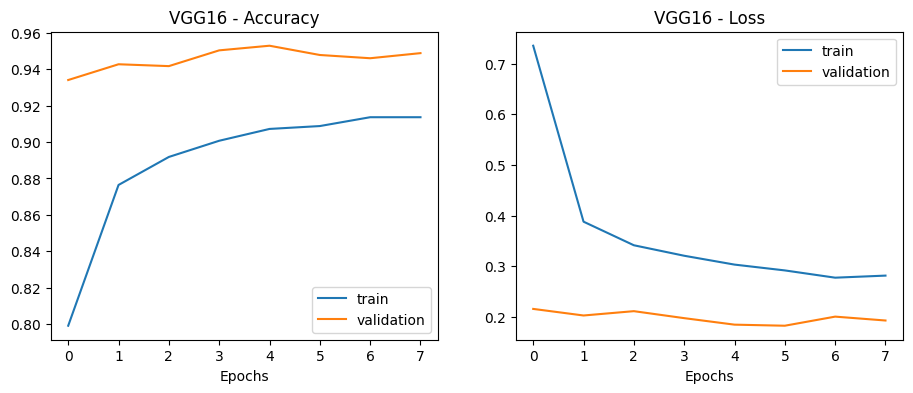

VGG16 test accuracy: 95.54%   macro F1: 94.93%


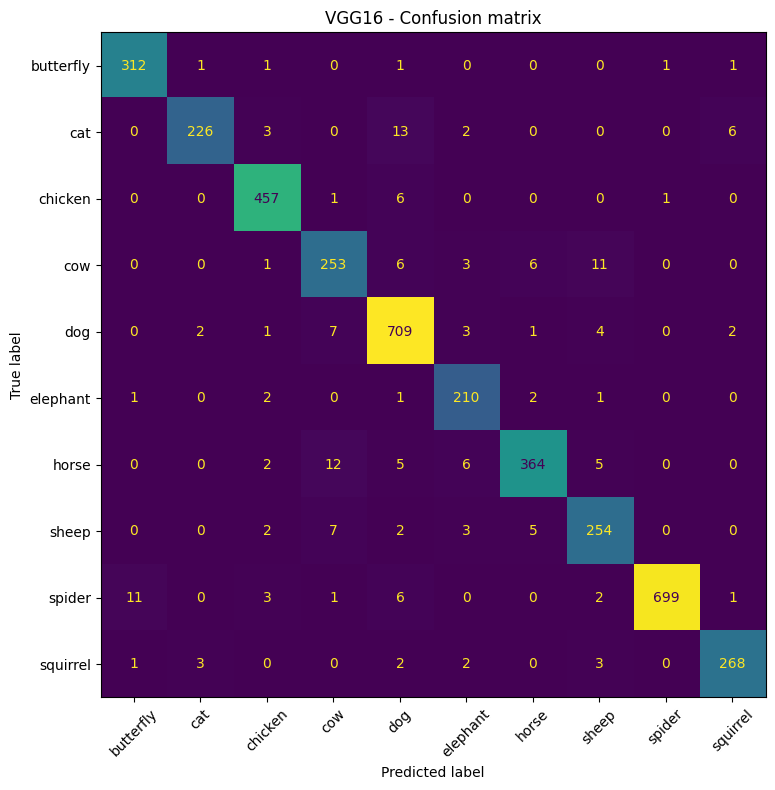

              precision    recall  f1-score   support

   butterfly       0.96      0.98      0.97       317
         cat       0.97      0.90      0.94       250
     chicken       0.97      0.98      0.98       465
         cow       0.90      0.90      0.90       280
         dog       0.94      0.97      0.96       729
    elephant       0.92      0.97      0.94       217
       horse       0.96      0.92      0.94       394
       sheep       0.91      0.93      0.92       273
      spider       1.00      0.97      0.98       723
    squirrel       0.96      0.96      0.96       279

    accuracy                           0.96      3927
   macro avg       0.95      0.95      0.95      3927
weighted avg       0.96      0.96      0.96      3927

{'test_acc_%': 95.54, 'macro_f1_%': 94.93, 'train_time_min': 14.8, 'total_params': 14848586, 'trainable_params': 133898}


In [10]:
train_v = make_ds("train", pre=vgg_pre)
val_v = make_ds("val", pre=vgg_pre)
test_v = make_ds("test", pre=vgg_pre)

vgg16, vgg_base = build(VGG16)
vgg16.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
es = tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

t0 = time.time()
h16 = vgg16.fit(train_v, validation_data=val_v, epochs=8, callbacks=[es])
time16 = time.time() - t0
print(f"Training time: {time16 / 60:.1f} min")

plot_history(h16, "VGG16")
acc, f1 = evaluate_model(vgg16, test_v, "VGG16")
record("VGG16 (frozen base)", vgg16, acc, f1, time16)
vgg16.save("vgg16_multi.keras")

In [11]:
for n in ["vgg16", "vgg_base", "train_v", "val_v", "test_v"]:
    globals().pop(n, None)
tf.keras.backend.clear_session()
gc.collect()
print("Memory cleared")

Memory cleared


## 9. Model 2: EfficientNetV2B0


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 76s 56ms/step - accuracy: 0.9312 - loss: 0.2371 - val_accuracy: 0.9781 - val_loss: 0.0779
Epoch 2/10
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 60s 53ms/step - accuracy: 0.9511 - loss: 0.1601 - val_accuracy: 0.9778 - val_loss: 0.0771
Epoch 3/10
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 60s 52ms/step - accuracy: 0.9559 - loss: 0.1475 - val_accuracy: 0.9794 - val_loss: 0.0797
Epoch 4/10
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 61s 53ms/step - accuracy: 0.9572 - loss: 0.1352 - val_accuracy: 0.9794 - val_loss: 0.0839
Epoch 5/10
1146/1146 ━━━━━━━━━━━━━━━━━━━━ 61s 53ms/step - accuracy: 0.9616 - loss: 0.1221 - val_accuracy: 0.9771 - val_loss: 0.0849
Training time: 5.3 min


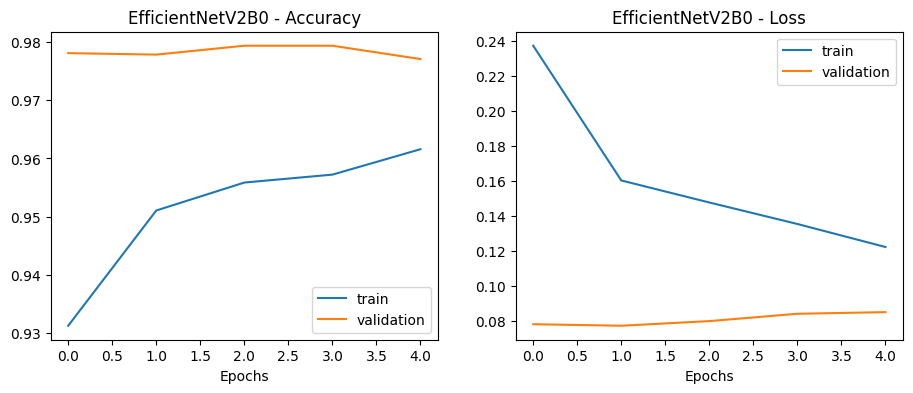

EfficientNetV2B0 test accuracy: 98.06%   macro F1: 97.81%


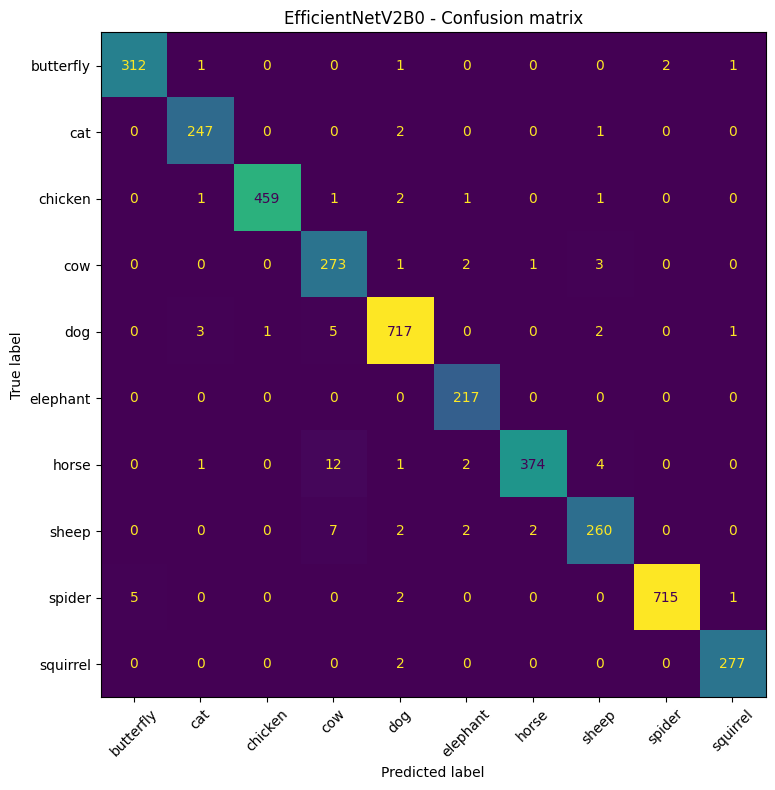

              precision    recall  f1-score   support

   butterfly       0.98      0.98      0.98       317
         cat       0.98      0.99      0.98       250
     chicken       1.00      0.99      0.99       465
         cow       0.92      0.97      0.94       280
         dog       0.98      0.98      0.98       729
    elephant       0.97      1.00      0.98       217
       horse       0.99      0.95      0.97       394
       sheep       0.96      0.95      0.96       273
      spider       1.00      0.99      0.99       723
    squirrel       0.99      0.99      0.99       279

    accuracy                           0.98      3927
   macro avg       0.98      0.98      0.98      3927
weighted avg       0.98      0.98      0.98      3927

{'test_acc_%': 98.06, 'macro_f1_%': 97.81, 'train_time_min': 5.3, 'total_params': 6249818, 'trainable_params': 330506}


In [12]:
train_e = make_ds("train")
val_e = make_ds("val")
test_e = make_ds("test")

effnet, eff_base = build(EfficientNetV2B0)
effnet.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
es = tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

t0 = time.time()
heff = effnet.fit(train_e, validation_data=val_e, epochs=10, callbacks=[es])
timeeff = time.time() - t0
print(f"Training time: {timeeff / 60:.1f} min")

plot_history(heff, "EfficientNetV2B0")
acc, f1 = evaluate_model(effnet, test_e, "EfficientNetV2B0")
record("EfficientNetV2B0 (frozen base)", effnet, acc, f1, timeeff)
effnet.save("effnetv2_multi.keras")

In [13]:
for n in ["effnet", "eff_base", "train_e", "val_e", "test_e"]:
    globals().pop(n, None)
tf.keras.backend.clear_session()
gc.collect()
print("Memory cleared")

Memory cleared


## 10. Results comparison table

                                test_acc_%  macro_f1_%  train_time_min  total_params  trainable_params
VGG16 (frozen base)                  95.54       94.93            14.8    14848586.0          133898.0
EfficientNetV2B0 (frozen base)       98.06       97.81             5.3     6249818.0          330506.0


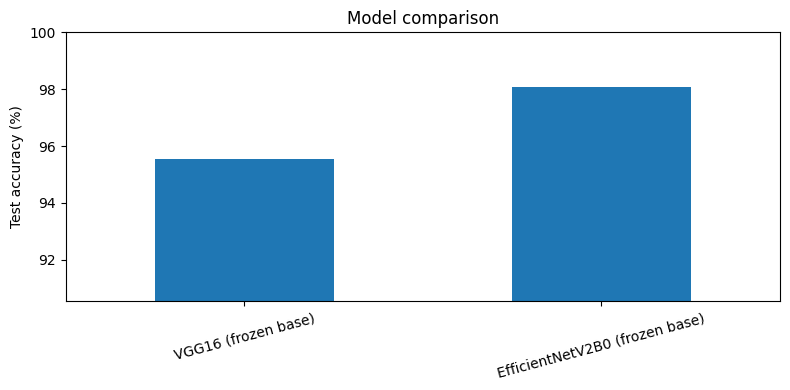

In [14]:
import pandas as pd
results = json.load(open("results.json"))
df = pd.DataFrame(results).T
print(df.to_string())

df["test_acc_%"].plot(kind="bar", figsize=(8, 4), rot=15, ylim=(max(0, df["test_acc_%"].min() - 5), 100))
plt.ylabel("Test accuracy (%)")
plt.title("Model comparison")
plt.tight_layout()
plt.show()

## 11. Visualization: feature maps (VGG16) and Grad-CAM heatmaps (both models)


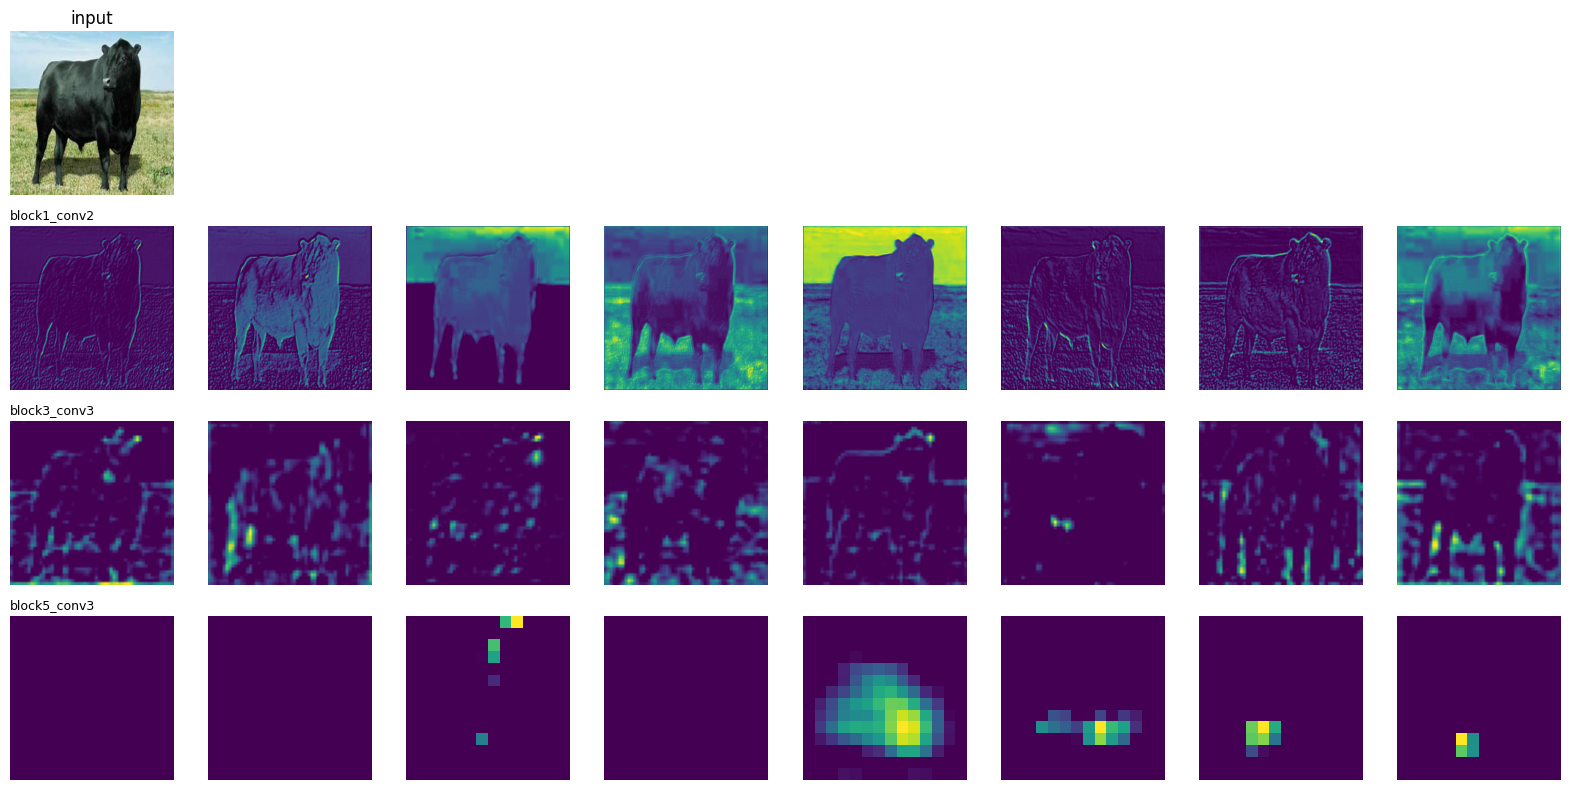

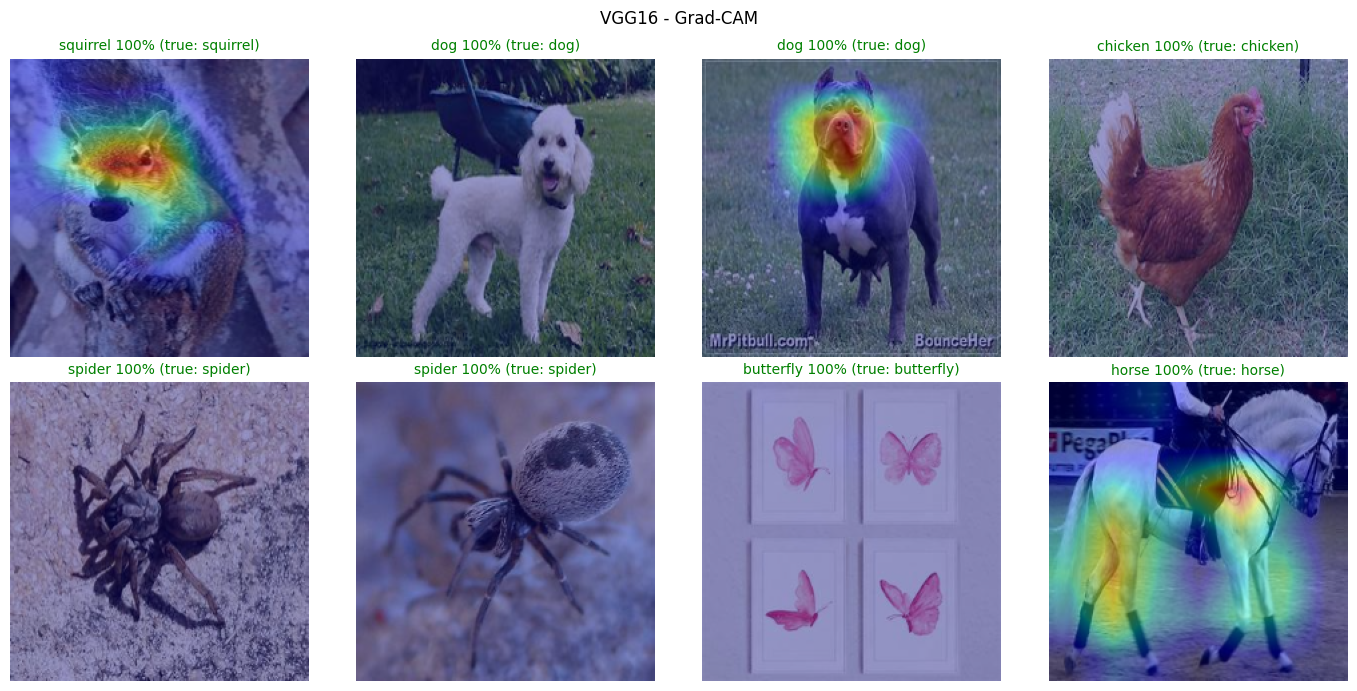

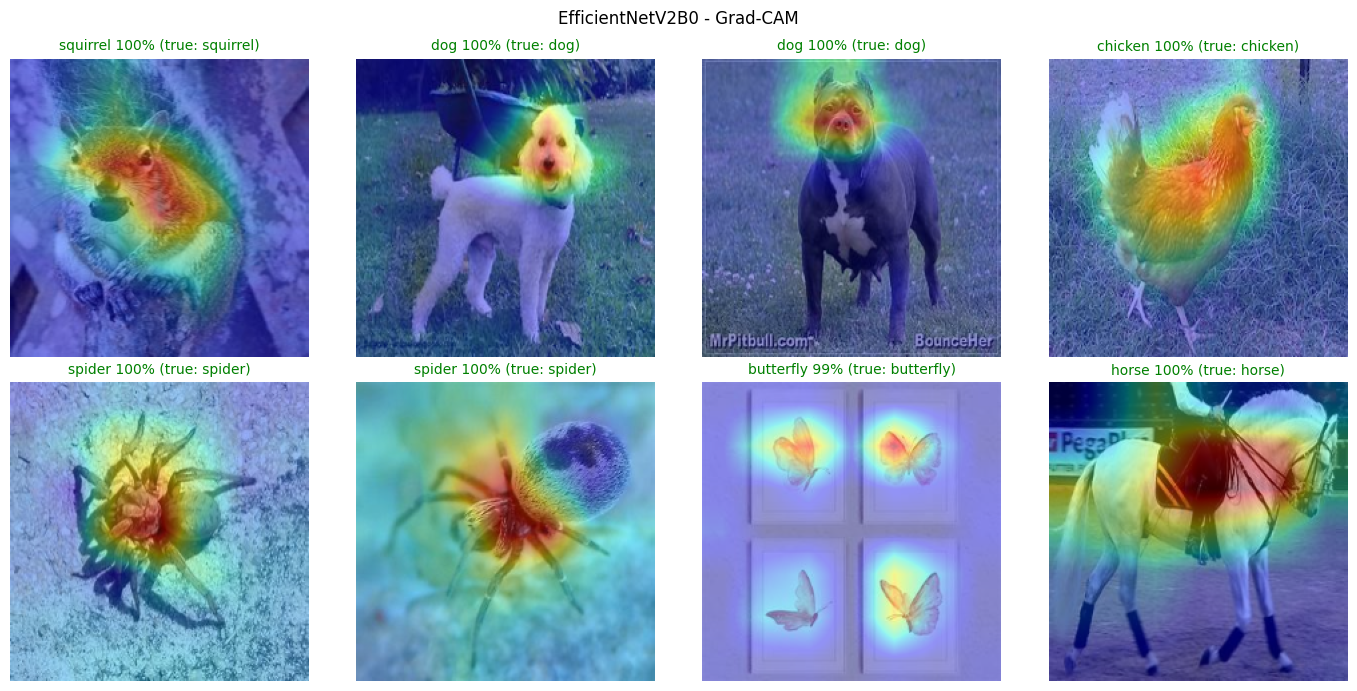

0

In [15]:
def find_base(model):
    # the pretrained network is the biggest nested model inside our model
    return max((l for l in model.layers if isinstance(l, tf.keras.Model)), key=lambda l: len(l.layers))


def gradcam(model, base, x_pre):
    head = model.layers[model.layers.index(base) + 1:]    # GlobalAveragePooling, Dense, Dropout, Dense
    conv_out = base(x_pre, training=False)                # last feature maps of the pretrained base
    with tf.GradientTape() as tape:
        tape.watch(conv_out)
        x = conv_out
        for l in head:
            x = l(x, training=False)
        cls = int(tf.argmax(x[0]))
        score = x[:, cls]
    grads = tape.gradient(score, conv_out)
    w = tf.reduce_mean(grads, axis=(1, 2))
    cam = tf.nn.relu(tf.reduce_sum(conv_out * w[:, None, None, :], axis=-1))[0].numpy()
    cam = cam / (cam.max() + 1e-8)
    return cam, x[0].numpy()


def show_gradcam(model, pre, title, skip=3):
    base = find_base(model)
    raw_test = make_ds("test")
    for xb, yb in raw_test.skip(skip).take(1):
        xp = pre(tf.identity(xb)) if pre is not None else xb
        plt.figure(figsize=(14, 7))
        for i in range(8):
            cam, probs = gradcam(model, base, xp[i:i + 1])
            cam_r = tf.image.resize(cam[..., None], (IMG, IMG)).numpy()[..., 0]
            heat = cm.jet(cam_r)[..., :3]
            img = np.clip(xb[i].numpy() / 255.0, 0, 1)
            overlay = np.clip(0.6 * img + 0.4 * heat, 0, 1)
            pred, true = int(np.argmax(probs)), int(yb[i])
            plt.subplot(2, 4, i + 1)
            plt.imshow(overlay)
            plt.axis("off")
            plt.title(f"{class_names[pred]} {probs[pred] * 100:.0f}% (true: {class_names[true]})",
                      color="green" if pred == true else "red", fontsize=10)
        plt.suptitle(title + " - Grad-CAM")
        plt.tight_layout()
        plt.show()


def show_feature_maps(model, pre, layer_names, n_filters=8):
    base = find_base(model)
    xb, _ = next(iter(make_ds("test", bs=1)))
    xp = pre(tf.identity(xb)) if pre is not None else xb
    fm_model = tf.keras.Model(base.inputs, [base.get_layer(n).output for n in layer_names])
    outs = fm_model(xp, training=False)
    fig, axes = plt.subplots(len(layer_names) + 1, n_filters, figsize=(2 * n_filters, 2 * (len(layer_names) + 1)))
    for ax in axes.flat:
        ax.axis("off")
    axes[0][0].imshow(np.clip(xb[0].numpy(), 0, 255).astype("uint8"))
    axes[0][0].set_title("input")
    for r, (name, o) in enumerate(zip(layer_names, outs), start=1):
        o = o[0].numpy()
        for j in range(n_filters):
            axes[r][j].imshow(o[:, :, j], cmap="viridis")
        axes[r][0].set_title(name, fontsize=9, loc="left")
    plt.tight_layout()
    plt.show()


p16 = "vgg16_multi_ft.keras" if os.path.exists("vgg16_multi_ft.keras") else "vgg16_multi.keras"
m16 = tf.keras.models.load_model(p16)
show_feature_maps(m16, vgg_pre, ["block1_conv2", "block3_conv3", "block5_conv3"])
show_gradcam(m16, vgg_pre, "VGG16")
del m16
tf.keras.backend.clear_session()
gc.collect()

meff = tf.keras.models.load_model("effnetv2_multi.keras")
show_gradcam(meff, None, "EfficientNetV2B0")
del meff
tf.keras.backend.clear_session()
gc.collect()

In [16]:
from google.colab import drive
drive.mount("/content/drive")
!cp /content/drive/MyDrive/animals_project/* /content/
!ls -lh /content/*.keras /content/results.json

Mounted at /content/drive
-rw-r--r-- 1 root root 28M Oct  9 19:19 /content/effnetv2_multi.keras
-rw-r--r-- 1 root root 353 Oct  9 19:19 /content/results.json
-rw-r--r-- 1 root root 58M Oct  9 19:19 /content/vgg16_multi.keras


## 12. Predicting Unseen Image

Saving dog.jpg to dog.jpg


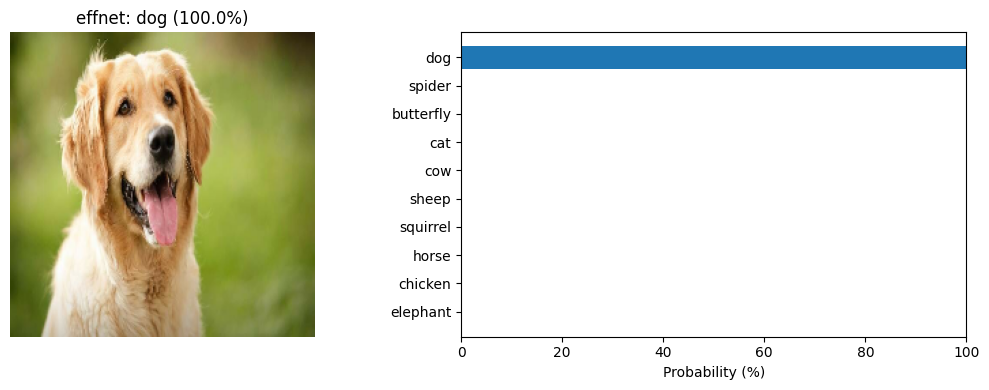

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from google.colab import files
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_pre

IMG = 224
class_names = ["butterfly", "cat", "chicken", "cow", "dog", "elephant", "horse", "sheep", "spider", "squirrel"]

models = {
    "effnet": (tf.keras.models.load_model("/content/effnetv2_multi.keras"), None),
    "vgg16":  (tf.keras.models.load_model("/content/vgg16_multi.keras"), vgg_pre),
}

def predict_photo(which="effnet"):
    model, pre = models[which]
    up = files.upload()
    for name, data in up.items():
        img = tf.io.decode_image(data, channels=3, expand_animations=False)
        img = tf.image.resize(img, (IMG, IMG))[None]
        x = pre(tf.identity(img)) if pre is not None else img
        probs = model(x, training=False).numpy()[0]
        order = np.argsort(probs)[::-1]
        fig, ax = plt.subplots(1, 2, figsize=(11, 4))
        ax[0].imshow(np.clip(img[0].numpy(), 0, 255).astype("uint8"))
        ax[0].axis("off")
        ax[0].set_title(f"{which}: {class_names[order[0]]} ({probs[order[0]]*100:.1f}%)")
        ax[1].barh([class_names[i] for i in order[::-1]], probs[order[::-1]] * 100)
        ax[1].set_xlabel("Probability (%)")
        ax[1].set_xlim(0, 100)
        plt.tight_layout()
        plt.show()

predict_photo("effnet")

Saving butterfly.jpg to butterfly.jpg


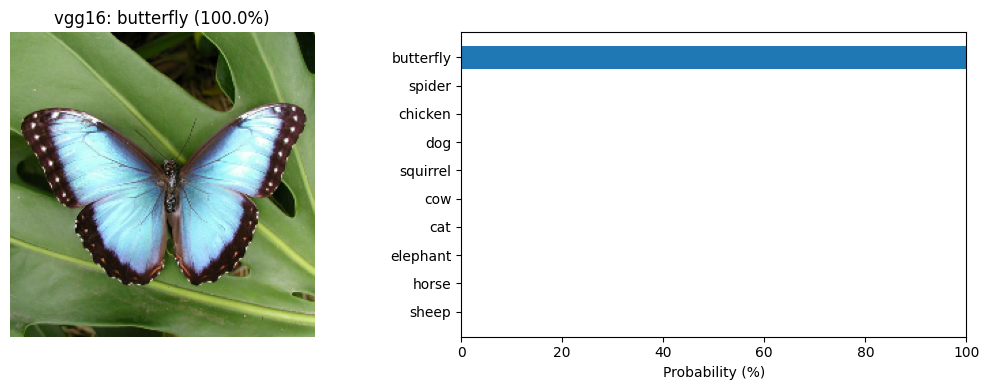

In [18]:
predict_photo("vgg16")

In [22]:
import os, shutil
from google.colab import drive
drive.mount("/content/drive")
dst = "/content/drive/MyDrive/animals_project"
os.makedirs(dst, exist_ok=True)
for f in ["effnetv2_multi.keras", "vgg16_multi.keras", "vgg16_multi_ft.keras", "results.json"]:
    p = f"/content/{f}"
    if os.path.exists(p):
        shutil.copy2(p, f"{dst}/{f}")
        print("Saved to Drive:", f)
    else:
        print("Not in this session:", f)
print(os.listdir(dst))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to Drive: effnetv2_multi.keras
Saved to Drive: vgg16_multi.keras
Not in this session: vgg16_multi_ft.keras
Saved to Drive: results.json
['effnetv2_multi.keras', 'vgg16_multi.keras', 'results.json', 'models', 'histories', 'results']
